In [1]:
import pandas as pd

data = {
    "Month": [
        "2024-01", "2024-02", "2024-03", "2024-04",
        "2024-05", "2024-06", "2024-07", "2024-08",
        "2024-09", "2024-10", "2024-11", "2024-12",
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    "Sales": [
        12000, 13500, 12800, 14200,
        15000, 15800, 16500, 17200,
        16800, 18000, 19500, 21000,
        20500, 21800, 22500, 23200,
        24500, 25200, 26000, 27500,
        26800, 28500, 30000, 31500
    ]
}

df = pd.DataFrame(data)

df.head()

,Month,Sales
0,2024-01,12000
1,2024-02,13500
2,2024-03,12800
3,2024-04,14200
4,2024-05,15000


In [2]:
df.to_csv("Dataset/historical_sales.csv", index=False)

print("Dataset saved successfully!")

PermissionError: [Errno 13] Permission denied: 'Dataset/historical_sales.csv'

In [3]:
# Check the dataset information
print("Dataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Convert Month into date format
df["Month"] = pd.to_datetime(df["Month"])

# Sort the data by month
df = df.sort_values("Month")

# Remove duplicate rows
df = df.drop_duplicates()

print("\nData after cleaning:")
print(df.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   24 non-null     str  
 1   Sales   24 non-null     int64
dtypes: int64(1), str(1)
memory usage: 684.0 bytes

Missing Values:
Month    0
Sales    0
dtype: int64

Data after cleaning:
       Month  Sales
0 2024-01-01  12000
1 2024-02-01  13500
2 2024-03-01  12800
3 2024-04-01  14200
4 2024-05-01  15000


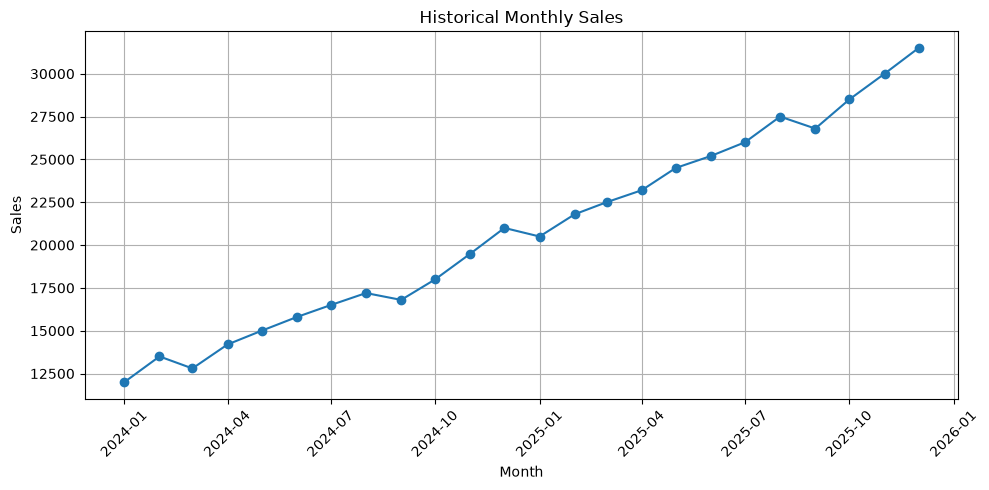

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(df["Month"], df["Sales"], marker="o")

plt.title("Historical Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Create a numerical time variable
df["Time"] = range(1, len(df) + 1)

# Input and target
X = df[["Time"]]
y = df["Sales"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 19
Testing data: 5


In [6]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [7]:
# Predict sales for the test data
y_pred = model.predict(X_test)

print("Predicted Sales:")
print(y_pred)

Predicted Sales:
[18018.25396825 24514.38631791 11522.1216186  26138.41940532
 20454.30359937]


In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error (MAE): 478.93
R² Score: 0.98


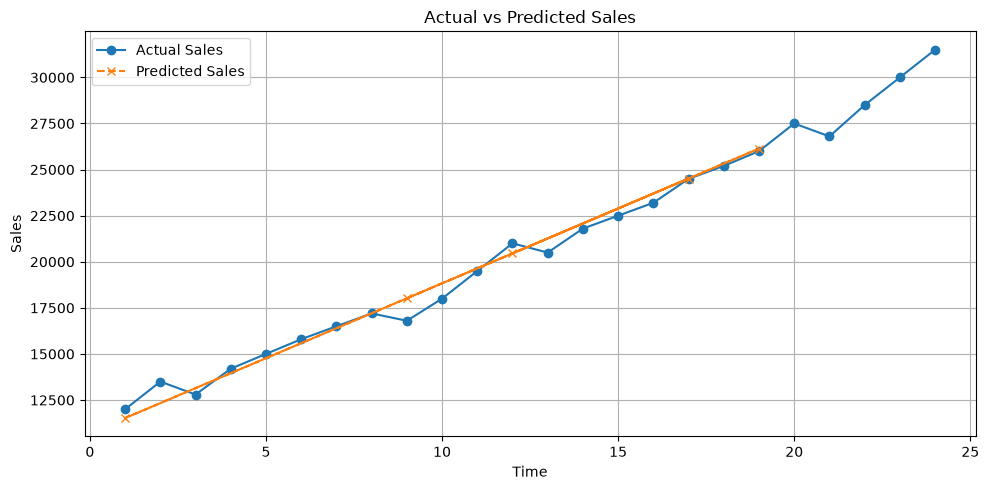

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(df["Time"], df["Sales"], marker="o", label="Actual Sales")
plt.plot(X_test["Time"], y_pred, marker="x", linestyle="--", label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Predict sales for the next 6 months

future_time = pd.DataFrame({
    "Time": range(len(df) + 1, len(df) + 7)
})

future_predictions = model.predict(future_time)

future_sales = pd.DataFrame({
    "Future_Month": [
        "2026-01", "2026-02", "2026-03",
        "2026-04", "2026-05", "2026-06"
    ],
    "Predicted_Sales": future_predictions
})

future_sales["Predicted_Sales"] = future_sales["Predicted_Sales"].round(2)

print(future_sales)

  Future_Month  Predicted_Sales
0      2026-01         31010.52
1      2026-02         31822.54
2      2026-03         32634.55
3      2026-04         33446.57
4      2026-05         34258.58
5      2026-06         35070.60


In [ ]:
future_sales.to_csv(
    "Output/future_sales_predictions.csv",
    index=False
)

print("Future predictions saved successfully!")

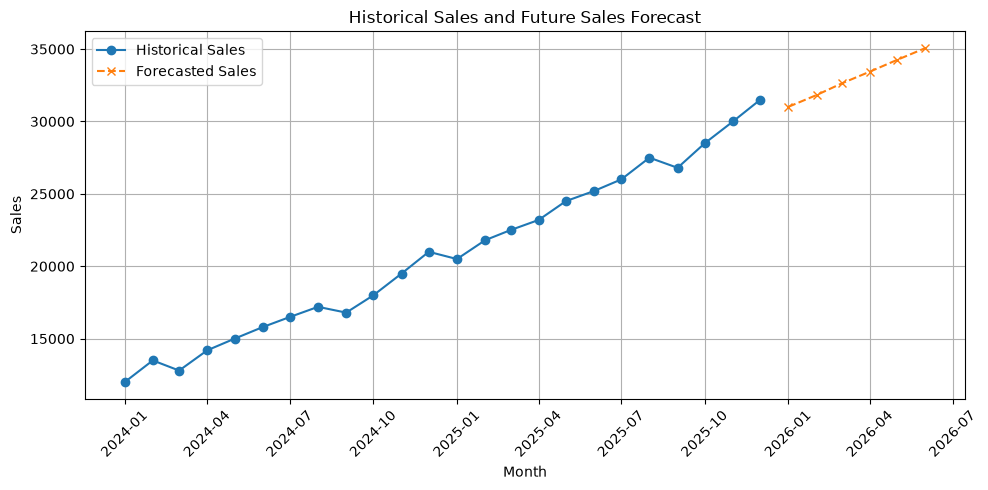

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(df["Month"], df["Sales"], marker="o", label="Historical Sales")

future_months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

plt.plot(
    future_months,
    future_predictions,
    marker="x",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Output/sales_forecast.png", dpi=300)
plt.show()

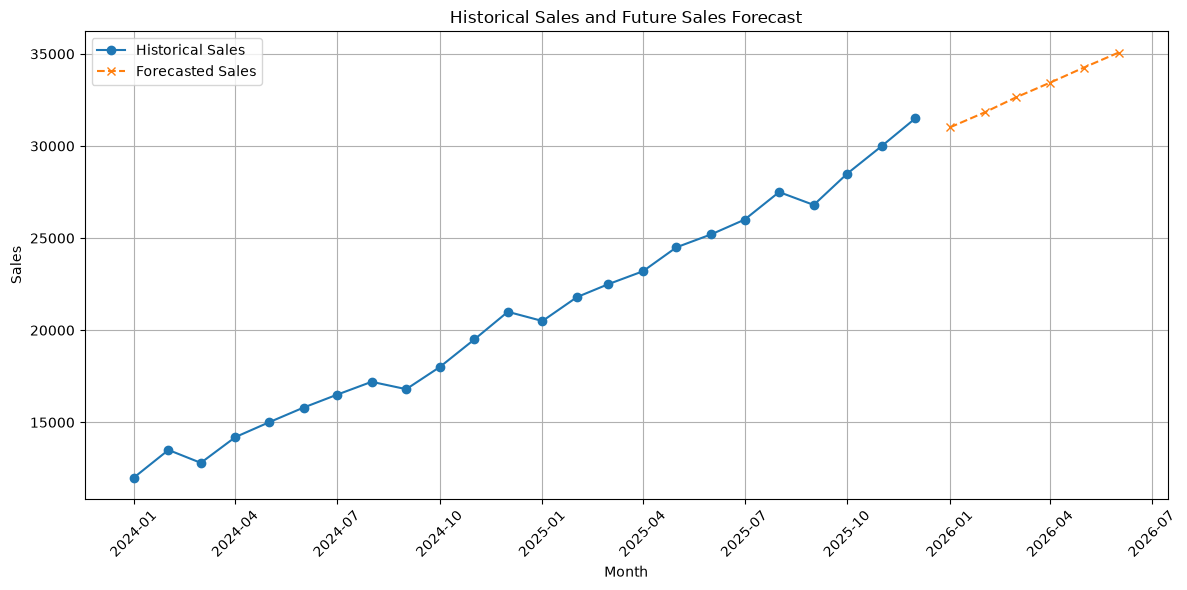

Forecast graph created successfully!


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Historical dates
historical_months = df["Month"]

# Future dates
future_months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

# Create the graph
plt.figure(figsize=(12, 6))

plt.plot(
    historical_months,
    df["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_months,
    future_predictions,
    marker="x",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

# Save the graph
plt.savefig(
    "Output/sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Forecast graph created successfully!")

In [13]:
# Recreate and save the historical sales dataset

data = {
    "Month": [
        "2024-01", "2024-02", "2024-03", "2024-04",
        "2024-05", "2024-06", "2024-07", "2024-08",
        "2024-09", "2024-10", "2024-11", "2024-12",
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    "Sales": [
        12000, 13500, 12800, 14200,
        15000, 15800, 16500, 17200,
        16800, 18000, 19500, 21000,
        20500, 21800, 22500, 23200,
        24500, 25200, 26000, 27500,
        26800, 28500, 30000, 31500
    ]
}

df = pd.DataFrame(data)

# Save the dataset
df.to_csv("Dataset/historical_sales.csv", index=False)

print("Historical sales CSV created successfully!")
print("Number of rows:", len(df))
print(df.head())

PermissionError: [Errno 13] Permission denied: 'Dataset/historical_sales.csv'

In [14]:
# Recreate and save the historical sales dataset

data = {
    "Month": [
        "2024-01", "2024-02", "2024-03", "2024-04",
        "2024-05", "2024-06", "2024-07", "2024-08",
        "2024-09", "2024-10", "2024-11", "2024-12",
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    "Sales": [
        12000, 13500, 12800, 14200,
        15000, 15800, 16500, 17200,
        16800, 18000, 19500, 21000,
        20500, 21800, 22500, 23200,
        24500, 25200, 26000, 27500,
        26800, 28500, 30000, 31500
    ]
}

df = pd.DataFrame(data)

# Save the dataset
df.to_csv("Dataset/historical_sales.csv", index=False)

print("Historical sales CSV created successfully!")
print("Number of rows:", len(df))
print(df.head())

PermissionError: [Errno 13] Permission denied: 'Dataset/historical_sales.csv'

In [15]:
print("Jupyter is working")

Jupyter is working


In [16]:
import pandas as pd
from pathlib import Path

# Create historical sales data
data = {
    "Month": [
        "2024-01", "2024-02", "2024-03", "2024-04",
        "2024-05", "2024-06", "2024-07", "2024-08",
        "2024-09", "2024-10", "2024-11", "2024-12",
        "2025-01", "2025-02", "2025-03", "2025-04",
        "2025-05", "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    "Sales": [
        12000, 13500, 12800, 14200,
        15000, 15800, 16500, 17200,
        16800, 18000, 19500, 21000,
        20500, 21800, 22500, 23200,
        24500, 25200, 26000, 27500,
        26800, 28500, 30000, 31500
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the complete table
display(df)

# Find the project folder
project_folder = Path.cwd()

# Save inside Dataset folder
dataset_folder = project_folder / "Dataset"
dataset_folder.mkdir(exist_ok=True)

csv_file = dataset_folder / "historical_sales.csv"
df.to_csv(csv_file, index=False)

print("\nDataset created successfully!")
print("Rows:", len(df))
print("Saved to:", csv_file)

,Month,Sales
0,2024-01,12000
1,2024-02,13500
2,2024-03,12800
3,2024-04,14200
4,2024-05,15000
5,2024-06,15800
6,2024-07,16500
7,2024-08,17200
8,2024-09,16800
9,2024-10,18000


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\PRATIKSHYA\\Downloads\\Predictive_Analytics_Project\\Dataset\\historical_sales.csv'

In [17]:
df.to_csv("Dataset/historical_sales.csv", index=False)

print("Dataset saved successfully!")
print("Rows:", len(df))

Dataset saved successfully!
Rows: 24


C:\Users\PRATIKSHYA\AppData\Local\Temp\ipykernel_23964\2866678789.py:28: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x00000244B90E4AD0>.

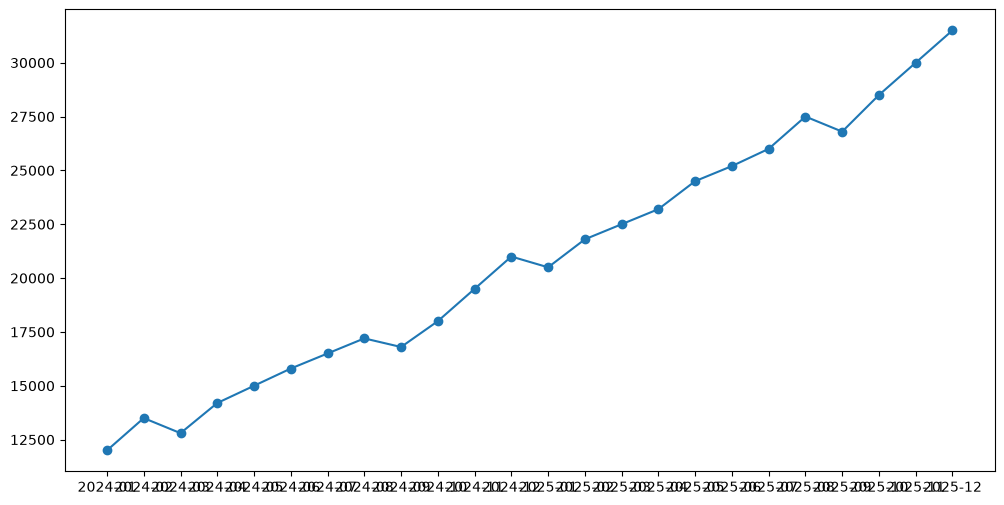

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure the model predictions exist
future_time = pd.DataFrame({
    "Time": range(len(df) + 1, len(df) + 7)
})

future_predictions = model.predict(future_time)

# Future months
future_months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

# Create the forecast graph
plt.figure(figsize=(12, 6))

plt.plot(
    df["Month"],
    df["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_months,
    future_predictions,
    marker="x",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()

# Save the graph
plt.savefig(
    "Output/sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Forecast graph saved successfully!")

In [19]:
print(type(df))
print(type(model))
print(type(future_predictions) if "future_predictions" in globals() else "future_predictions does not exist")

<class 'pandas.DataFrame'>
<class 'sklearn.linear_model._base.LinearRegression'>
<class 'numpy.ndarray'>


In [20]:
future_sales.to_csv(
    "Output/future_sales_predictions.csv",
    index=False
)

print("Future predictions saved successfully!")

Future predictions saved successfully!
